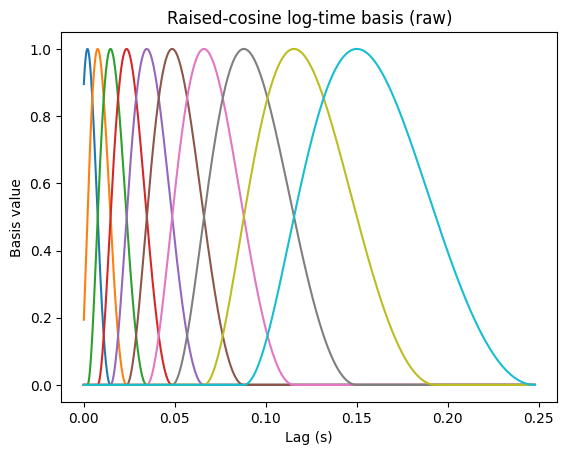

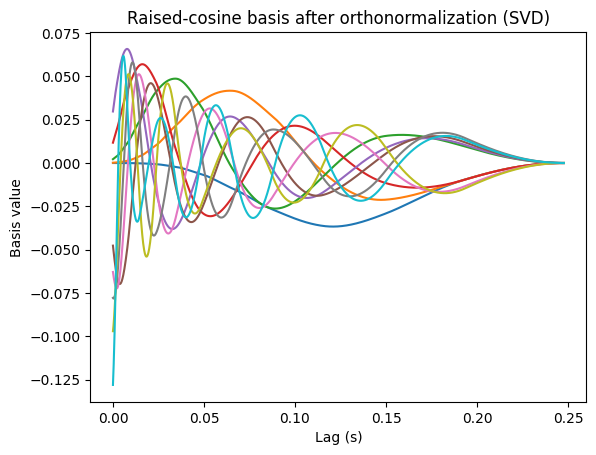

In [3]:
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
# from utils.CBEM import CBEM


nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

dt = 1e-4

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
# CBEM.stimNumBasisVectors = size(CBEM.stimBasisVectors,2);
stimNumBasisVectors = B_orth.shape[1]


plt.figure()
plt.plot(t, B_raw)
plt.xlabel("Lag (s)")
plt.ylabel("Basis value")
plt.title("Raised-cosine log-time basis (raw)")
plt.show()

plt.figure()
plt.plot(t, B_orth)
plt.xlabel("Lag (s)")
plt.ylabel("Basis value")
plt.title("Raised-cosine basis after orthonormalization (SVD)")
plt.show()


In [4]:
import numpy as np

def make_spike_history_basis(
    n_shfilters,
    dt,
    num_short_blocks=5,
    refractory_block_length_s=0.4e-3,
    sh_end=90e-3,
    b=1e-4,
    makeRaisedCosBasis_fn=None,
):
    """
    Build hybrid spike-history basis:
      - short block basis for refractory period
      - raised-cosine basis for longer lags

    Parameters
    ----------
    n_shfilters : int
        Total number of spike-history basis vectors.
    dt : float
        Bin size in seconds.
    num_short_blocks : int
        Number of short block basis vectors.
    refractory_block_length_s : float
        Width of each short refractory block in seconds.
    sh_end : float
        End of spike-history window in seconds.
    b : float
        Raised-cosine warping parameter.
    makeRaisedCosBasis_fn : callable
        Function with MATLAB-like behavior returning basis matrix
        for raised cosine part. Expected output basis shape [L, P].

    Returns
    -------
    B_hist : ndarray, shape [L, P]
        Full spike-history basis.
    info : dict
        Metadata.
    """
    refractory_block_length = int(round(refractory_block_length_s / dt))
    refractory_block_length_s = refractory_block_length * dt

    n_short = min(num_short_blocks, n_shfilters)

    if n_shfilters > num_short_blocks:
        sh_start = refractory_block_length_s * num_short_blocks

        # basis2 should cover from SHstart to SHend
        _, basis2, basis2_0 = makeRaisedCosBasis_fn(
            n_shfilters - num_short_blocks,
            dt,
            [sh_start, sh_end],
            b
        )

        # zero out early refractory region
        early_bins = num_short_blocks * refractory_block_length
        basis2[:early_bins, :] = 0.0
        filter_length = basis2.shape[0]
    else:
        basis2 = np.zeros((num_short_blocks * refractory_block_length, 0))
        basis2_0 = None
        filter_length = num_short_blocks * refractory_block_length
        sh_start = -1
        sh_end = -1

    # short refractory block basis
    basis1 = np.zeros((filter_length, n_short), dtype=float)
    for i in range(n_short):
        start = i * refractory_block_length
        stop = start + refractory_block_length
        basis1[start:stop, i] = 1.0 / refractory_block_length

    B_hist = np.concatenate([basis1, basis2], axis=1)

    info = {
        "refractory_block_length_bins": refractory_block_length,
        "refractory_block_length_s": refractory_block_length_s,
        "num_short_blocks": num_short_blocks,
        "sh_start": sh_start,
        "sh_end": sh_end,
        "basis2_0": basis2_0,
    }
    return B_hist, info

In [5]:
import numpy as np

def make_spike_history_basis(
    n_shfilters,
    dt,
    num_short_blocks=5,
    refractory_block_length_s=0.4e-3,
    sh_end=90e-3,
    b=1e-4,
    makeRaisedCosBasis_fn=None,
):
    """
    Build hybrid spike-history basis:
      - short block basis for refractory period
      - raised-cosine basis for longer lags

    Parameters
    ----------
    n_shfilters : int
        Total number of spike-history basis vectors.
    dt : float
        Bin size in seconds.
    num_short_blocks : int
        Number of short block basis vectors.
    refractory_block_length_s : float
        Width of each short refractory block in seconds.
    sh_end : float
        End of spike-history window in seconds.
    b : float
        Raised-cosine warping parameter.
    makeRaisedCosBasis_fn : callable
        Function with MATLAB-like behavior returning basis matrix
        for raised cosine part. Expected output basis shape [L, P].

    Returns
    -------
    B_hist : ndarray, shape [L, P]
        Full spike-history basis.
    info : dict
        Metadata.
    """
    refractory_block_length = int(round(refractory_block_length_s / dt))
    refractory_block_length_s = refractory_block_length * dt

    n_short = min(num_short_blocks, n_shfilters)

    if n_shfilters > num_short_blocks:
        sh_start = refractory_block_length_s * num_short_blocks

        # basis2 should cover from SHstart to SHend
        _, basis2, basis2_0 = makeRaisedCosBasis_fn(
            n_shfilters - num_short_blocks,
            dt,
            [sh_start, sh_end],
            b
        )

        # zero out early refractory region
        early_bins = num_short_blocks * refractory_block_length
        basis2[:early_bins, :] = 0.0
        filter_length = basis2.shape[0]
    else:
        basis2 = np.zeros((num_short_blocks * refractory_block_length, 0))
        basis2_0 = None
        filter_length = num_short_blocks * refractory_block_length
        sh_start = -1
        sh_end = -1

    # short refractory block basis
    basis1 = np.zeros((filter_length, n_short), dtype=float)
    for i in range(n_short):
        start = i * refractory_block_length
        stop = start + refractory_block_length
        basis1[start:stop, i] = 1.0 / refractory_block_length

    B_hist = np.concatenate([basis1, basis2], axis=1)

    info = {
        "refractory_block_length_bins": refractory_block_length,
        "refractory_block_length_s": refractory_block_length_s,
        "num_short_blocks": num_short_blocks,
        "sh_start": sh_start,
        "sh_end": sh_end,
        "basis2_0": basis2_0,
    }
    return B_hist, info

B_hist shape: (3154, 12)
{'refractory_block_length_bins': 4, 'refractory_block_length_s': 0.0004, 'num_short_blocks': 5, 'sh_start': 0.002, 'sh_end': 0.09, 'basis2_0': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 7.85739314e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.38882431e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 8.32084274e-09]], shape=(3154, 7))}


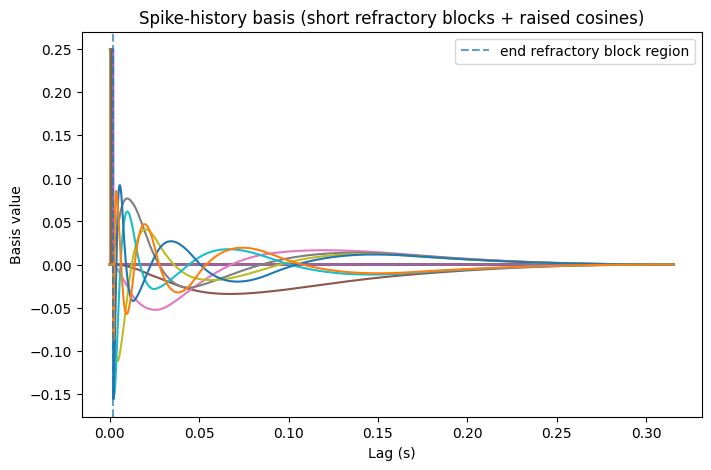

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# build spike-history basis
B_hist, info = make_spike_history_basis(
    n_shfilters=nSHfilters,
    dt=dt,
    num_short_blocks=numShortSHFilts,
    refractory_block_length_s=0.4e-3,   # 0.4 ms
    sh_end=90e-3,
    b=1e-4,
    makeRaisedCosBasis_fn=makeRaisedCosBasis
)

# time axis in seconds
t_hist = np.arange(B_hist.shape[0]) * dt

print("B_hist shape:", B_hist.shape)
print(info)

# ---- full spike-history basis ----
plt.figure(figsize=(8, 5))
plt.plot(t_hist, B_hist)
plt.xlabel("Lag (s)")
plt.ylabel("Basis value")
plt.title("Spike-history basis (short refractory blocks + raised cosines)")
plt.axvline(info["num_short_blocks"] * info["refractory_block_length_s"],
            linestyle="--", alpha=0.7, label="end refractory block region")
plt.legend()
plt.show()